In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# pd.set_option('display.max_colwidth', None)   # ne tronque plus les strings
# pd.set_option('display.width', None)         # évite les retours à la ligne forcés

# pd.reset_option('display.max_colwidth')
# pd.reset_option('display.width')

# Lecture du fichier Parquet
products = pd.read_parquet('data.parquet')
products = products.replace('', np.nan)
products = products.replace(' ', np.nan)
print(products.head())
print(products.info())

                                          product_id  cluster_id country_name  \
0  f64ac32912c7e35c542f1a8283307f90626c4bd6f2ba90...     7315001          USA   
1  6a8468dff98b78f1dae63693580ec0320612b64dff010d...    10172001          USA   
2  a6f41f9cb717f3a113e353d19449db9980b657e426edb6...    10172001          USA   
3  4a01eb7ffa3c09a6c9a7997ea509db95d3585ec449e675...    10172001          USA   
4  f112ef392486ec9fda707499f13dbbeb619c07829af6d5...    10177001          USA   

                                               title  \
0                               Clean Matte BB Cream   
1  LOreal Paris Magic Skin Beautifier BB Cream - ...   
2                     Magic Skin Beautifier BB Cream   
3  L'Oréal Paris Magic Skin Beautifier BB Cream, ...   
4  LOreal Youth Code BB Cream Illuminator SPF 15,...   

                                         description category_level_1_name  \
0   Won't clog pores Lasts all day Oil free BB cream                MakeUp   
1  Discover the secr

In [2]:
print(products.shape, '\n')
print(products.dtypes, '\n')
print(products.isna().sum(), '\n')
print(products.nunique(), '\n')

(74125, 12) 

product_id               object
cluster_id                Int64
country_name             object
title                    object
description              object
category_level_1_name    object
category_level_2_name    object
category_level_3_name    object
brand_name               object
url                      object
shade_name               object
image_filename           object
dtype: object 

product_id                   0
cluster_id                   0
country_name                 0
title                        0
description              15817
category_level_1_name        0
category_level_2_name        0
category_level_3_name        0
brand_name                   0
url                         10
shade_name                2071
image_filename               0
dtype: int64 

product_id               74125
cluster_id               26272
country_name                 2
title                    62475
description              36930
category_level_1_name        2
category_leve

In [3]:

# Assurez-vous d'avoir chargé votre DataFrame 'products' (depuis le fichier .parquet)
# products = pd.read_parquet('votre_fichier.parquet', engine='pyarrow') 

colonnes_a_analyser = [
    'category_level_3_name',
]

print("### 📊 Analyse des Colonnes de Catégorie ###\n")

for col in colonnes_a_analyser:
    if col in products.columns:
        num_unique = products[col].nunique()
        unique_values = products[col].unique().tolist()
        
        print(f"--- 🏷️ Colonne : {col} ({num_unique} valeurs uniques) ---")
        
        # Afficher la liste des valeurs
        # Utiliser l'affichage standard pour les colonnes de faible cardinalité
        if num_unique < 100:
            print(unique_values)
        else:
            # Pour le cas hypothétique où level 3 aurait beaucoup trop de valeurs
            print(f"-> Trop de valeurs uniques ({num_unique}) pour l'affichage complet.")
            print(f"-> Exemples des 10 premières valeurs: {unique_values[:10]}")
            
        print("\n")
    else:
        print(f"Avertissement : La colonne '{col}' n'existe pas dans le DataFrame.")

### 📊 Analyse des Colonnes de Catégorie ###

--- 🏷️ Colonne : category_level_3_name (34 valeurs uniques) ---
['BB Cream', 'Bleaching', 'Blush', 'Bronzer', 'CC Cream', 'Concealer', 'Contour', 'Cuticle Care', 'Developer', 'Direct Dye', 'Eye Liner', 'Eye Shadow', 'Eyebrow', 'Fake Lashes', 'Foundation', 'Hair Color Remover', 'Hair Makeup', 'Herbal Color', 'Highlighter', 'Lip Gloss', 'Lip Liner', 'Lip Tint', 'Lipstick', 'Mascara', 'Nail Adhesives', 'Nail Base', 'Nail Care', 'Nail Extension', 'Nail Polish', 'Permanent Color', 'Polish Remover', 'Primer', 'Setting', 'Tone-on-Tone']




In [4]:
# Filtrer les lignes dont le titre contient "rouge pur couture"
mask = products['title'].str.contains('rouge pur couture', case=False, na=False)
result = products[mask]

#print all the str
print(result.cluster_id, result.category_level_3_name, result.shade_name, result.url, '\n')


39079     97528001
39080     97528001
39081     97528001
39466    447295001
39468    447295001
41906     47722001
41907     47728001
41909     47728001
41918     47733001
41921     47733001
41922     47737001
41923     47737001
41925     47737001
41926     47737001
41928     47737001
41938     47755001
41939     47755001
41940     47755001
41941     47755001
41942     47755001
41943     47755001
41944     47755001
41945     47755001
41946     47755001
41947     47755001
41948     47755001
41949     47755001
41950     47755001
41951     47755001
42111     55955003
42112     55963003
42113     55963003
42114     55963003
42115     55963003
42116     55963003
42117     55963003
45201    238517001
45202    238517001
45668    277291001
46329    364748003
46330    364748003
46331    364748003
46674    417371001
46675    417371001
47972    515399001
Name: cluster_id, dtype: Int64 39079    Lip Tint
39080    Lip Tint
39081    Lip Tint
39466    Lip Tint
39468    Lip Tint
41906    Lipstick
41907 

In [5]:
index = 42112
print(products.loc[index].product_id)
print(products.loc[index].cluster_id)
print(products.loc[index].country_name)
print(products.loc[index].title)
print(products.loc[index].description)
print(products.loc[index].category_level_1_name)
print(products.loc[index].category_level_2_name)
print(products.loc[index].category_level_3_name)
print(products.loc[index].brand_name)
print(products.loc[index].url)
print(products.loc[index].shade_name)
print(products.loc[index].image_filename)

60c4f3e46ad6216e690f6d844337b3fb171e18f18298a616aa1151a2eaedf548
55963003
France
ROUGE PUR COUTURE Rouge à lèvres fini satin
ROUGE PUR COUTURE, le rouge à lèvre iconique de Yves Saint Laurent Beauté se réinvente.   Le nouveau rouge à lèvres à la couleur intense et au fini satiné s'enrichie de pigments purs qui fusionnent avec les lèvres pour un effet seconde peau.    Grâce à sa texture crémeuse, légère & confortable, Rouge Pur Couture s'applique sans effort pour habiller les lèvres d’une couleur éclatante dans un fini satiné couture, en un passage.    Enrichie à 80% d’ingrédients soin, la nouvelle formule se compose de céramides, de tubéreuse et d’extraits de figue de barbarie issus des Jardins Collectifs De L'Ourika YSL Beauté. Ces ingrédients hydratent et protègent les lèvres, jusqu’à 16H* de protection et de confort. Les lèvres sont plus douces et plus lisses à chaque application.    Les 30 nouvelles teintes de Rouge Pur Couture sont déclinées dans 4 familles de couleurs : Rouge, Nu

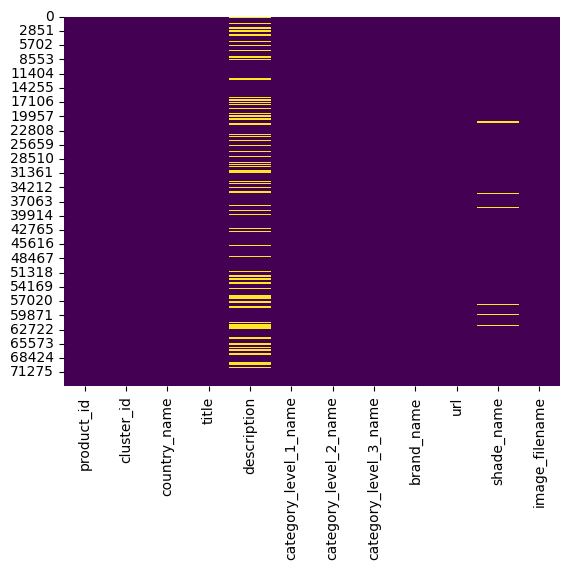

In [6]:
sns.heatmap(products.isnull(), cmap='viridis', cbar=False)
plt.show()


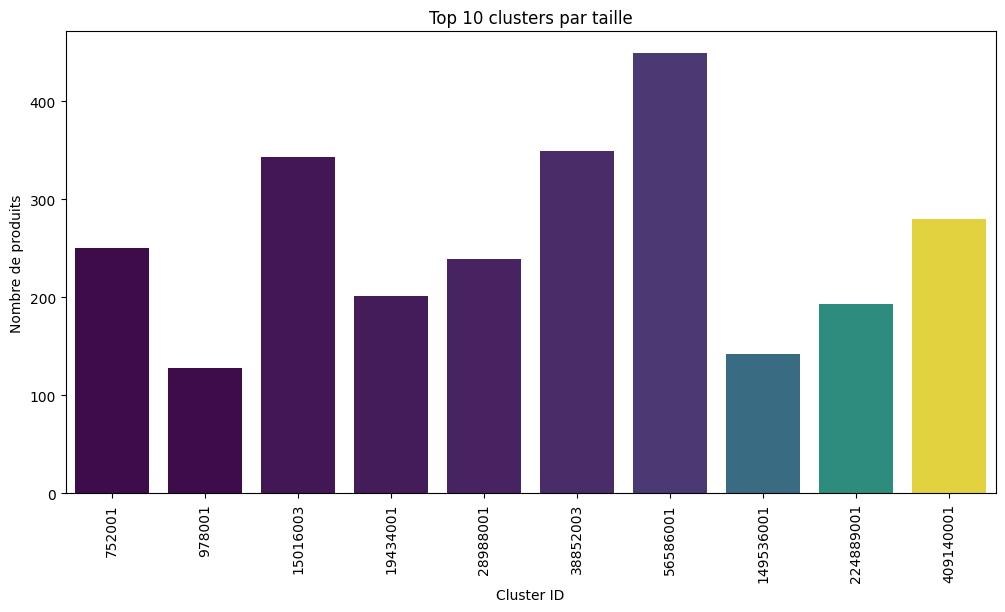

In [7]:
top_n = 10
top_clusters = products["cluster_id"].value_counts().head(top_n)
df_top = top_clusters.reset_index()
df_top.columns = ["cluster_id", "count"]

plt.figure(figsize=(12,6))
sns.barplot(
    data=df_top,
    x="cluster_id",
    y="count",
    hue="cluster_id",  # chaque cluster a sa couleur
    palette="viridis",
    legend=False        # pas besoin de légende
)
plt.xlabel("Cluster ID")
plt.ylabel("Nombre de produits")
plt.title(f"Top {top_n} clusters par taille")
plt.xticks(rotation=90)
plt.show()

In [11]:
cluster = 47755001  # Remplacez par le cluster_id souhaité
cluster_products = products[products["cluster_id"] == cluster]
print(f"Produits dans le cluster {cluster} :")
print(cluster_products[["shade_name"]])

Produits dans le cluster 47755001 :
                         shade_name
41938                   85 Nu Fatal
41939                 50 Rouge Neon
41940                            90
41941               No. 66 Rosewood
41942               No.14 Rouge Feu
41943  Satin finish - Standard size
41944                  13 Le Orange
41945            R21 Rouge Paradoxe
41946      No. 212 Alternative Plum
41947              Pink Celebration
41948  Satin finish - Standard size
41949                  83 Fiery Red
41950                   R1 Le Rouge
41951                  No. 70 Le Nu
